In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Load the Dataset

In [6]:
df=pd.read_csv('/content/placement_data.csv')

Understand the Data

In [7]:
df.head()

,Student_ID,Gender,Department,CGPA,Internships,Aptitude_Score,Communication_Score,Attendance,Placement_Status,Salary_LPA
0,S101,Male,CSE,8.5,2,78,82,90,Placed,7
1,S102,Female,ECE,7.2,1,65,75,85,Placed,5
2,S103,Male,EEE,6.8,0,55,60,80,Not Placed,0
3,S104,Female,CSE,9.1,3,88,91,95,Placed,12
4,S105,Male,MECH,7.0,1,62,68,78,Not Placed,0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Student_ID           80 non-null     object 
 1   Gender               80 non-null     object 
 2   Department           80 non-null     object 
 3   CGPA                 80 non-null     float64
 4   Internships          80 non-null     int64  
 5   Aptitude_Score       80 non-null     int64  
 6   Communication_Score  80 non-null     int64  
 7   Attendance           80 non-null     int64  
 8   Placement_Status     80 non-null     object 
 9   Salary_LPA           80 non-null     int64  
dtypes: float64(1), int64(5), object(4)
memory usage: 6.4+ KB


In [9]:
df.describe()

,CGPA,Internships,Aptitude_Score,Communication_Score,Attendance,Salary_LPA
count,80.000000,80.000000,80.000000,80.000000,80.000000,80.000000
mean,7.970000,1.825000,74.412500,78.850000,87.875000,7.150000
std,0.921254,1.319522,13.721178,12.869452,7.720391,5.661551
min,6.500000,0.000000,50.000000,56.000000,73.000000,0.000000
25%,7.100000,1.000000,63.000000,68.750000,81.750000,0.000000
50%,8.050000,2.000000,75.500000,80.500000,89.000000,7.000000
75%,8.800000,3.000000,86.250000,90.250000,94.250000,11.250000
max,9.500000,4.000000,97.000000,99.000000,100.000000,19.000000


Data Cleaning

In [10]:
df.isnull().sum()

,0
Student_ID,0
Gender,0
Department,0
CGPA,0
Internships,0
Aptitude_Score,0
Communication_Score,0
Attendance,0
Placement_Status,0
Salary_LPA,0


In [11]:
df.drop_duplicates(inplace=True)

Basic Analysis

Placement Count

In [12]:
df['Placement_Status'].value_counts()

,count
Placement_Status,
Placed,58
Not Placed,22


Average Salary

In [13]:
round(df[df['Placement_Status']=='Placed']['Salary_LPA'].mean(),2)

np.float64(9.86)

Department-wise Placement Count


In [14]:
df[df['Placement_Status']=='Placed'].groupby('Department')['Student_ID'].count()

,Student_ID
Department,
CIVIL,4
CSE,24
ECE,8
EEE,7
IT,14
MECH,1


Department-wise Average Salary

In [15]:
round(df[df['Placement_Status']=='Placed'].groupby('Department')['Salary_LPA'].mean(),2)

,Salary_LPA
Department,
CIVIL,5.25
CSE,13.88
ECE,6.88
EEE,5.14
IT,8.79
MECH,4.00


Gender-wise Placement Count

In [16]:
pd.crosstab(df['Gender'],df['Placement_Status'])

Placement_Status,Not Placed,Placed
Gender,,
Female,5,35
Male,17,23


Visualization

Placement Distribution


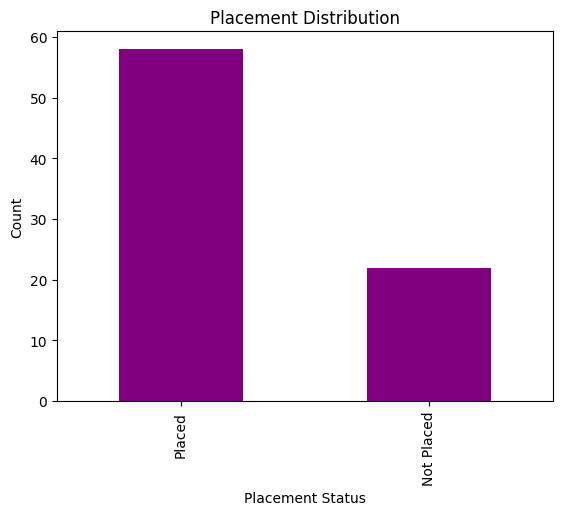

In [17]:
A=df['Placement_Status'].value_counts()
A.plot(kind='bar',color='purple')
plt.xlabel("Placement Status")
plt.ylabel("Count")
plt.title("Placement Distribution")
plt.show()

CGPA vs SALARY


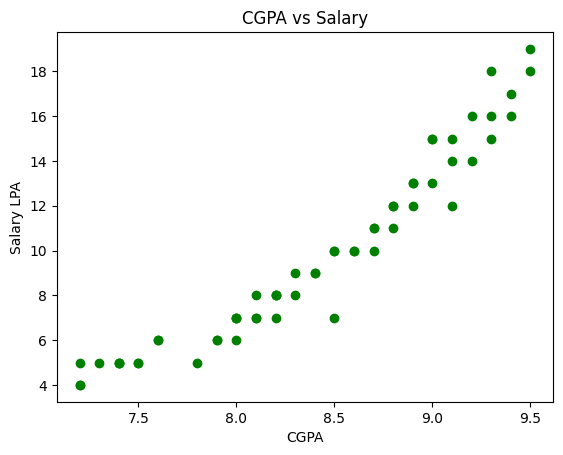

In [18]:
placed = df[df['Placement_Status']=='Placed']
plt.scatter(placed['CGPA'],placed['Salary_LPA'],color='green')
plt.xlabel("CGPA")
plt.ylabel("Salary LPA")
plt.title("CGPA vs Salary")
plt.show()

Correlation Analysis

In [19]:
placed = df[df['Placement_Status']=='Placed']
placed[['CGPA',
     'Internships',
     'Aptitude_Score',
     'Communication_Score',
     'Attendance',
     'Salary_LPA']].corr()

,CGPA,Internships,Aptitude_Score,Communication_Score,Attendance,Salary_LPA
CGPA,1.000000,0.931961,0.990985,0.982827,0.979616,0.955892
Internships,0.931961,1.000000,0.945070,0.941148,0.948744,0.940565
Aptitude_Score,0.990985,0.945070,1.000000,0.992085,0.990266,0.971998
Communication_Score,0.982827,0.941148,0.992085,1.000000,0.993242,0.969278
Attendance,0.979616,0.948744,0.990266,0.993242,1.000000,0.975458
Salary_LPA,0.955892,0.940565,0.971998,0.969278,0.975458,1.000000


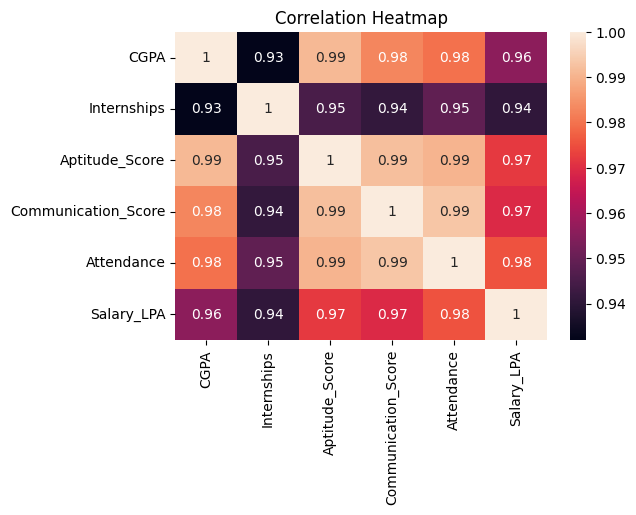

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(6,4))
sns.heatmap(
    placed[['CGPA',
            'Internships',
            'Aptitude_Score',
            'Communication_Score',
            'Attendance',
            'Salary_LPA']].corr(),
    annot=True
)
plt.title("Correlation Heatmap")
plt.show()

Machine Learning

In [21]:
X = df[['CGPA','Internships','Aptitude_Score']]
y = df['Placement_Status']

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

model = LogisticRegression()

model.fit(X_train,y_train)

LogisticRegression()

In [23]:
y_pred=model.predict(X_test)

In [24]:
from sklearn.metrics import accuracy_score
accuracy=accuracy_score(y_test,y_pred)
print("Accuracy is :",accuracy)

Accuracy is : 1.0


In [25]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

  Not Placed       1.00      1.00      1.00         4
      Placed       1.00      1.00      1.00        12

    accuracy                           1.00        16
   macro avg       1.00      1.00      1.00        16
weighted avg       1.00      1.00      1.00        16



In [27]:
new_student =pd.DataFrame({'CGPA':[8.7],
                           'Internships':[2],
                           'Aptitude_Score':[85]})
prediction = model.predict(new_student)
print(prediction)

['Placed']
